# Journey to the Moon

Os estados membros da ONU estão planejando enviar duas pessoas à Lua. Para promover a cooperação internacional, eles desejam que os dois astronautas sejam de **países diferentes**. Você receberá uma lista de pares de IDs de astronautas, onde cada dupla pertence ao mesmo país. Sua tarefa é determinar quantos pares de astronautas de países diferentes podem ser formados.

### ## Descrição do Problema

Existem $n$ astronautas numerados de $0$ a $n-1$. Você recebe uma lista de pares onde cada par $[u, v]$ indica que o astronauta $u$ e o astronauta $v$ possuem a mesma nacionalidade. Utilizando essas informações, você deve agrupar os astronautas por país e calcular o número total de combinações de dois astronautas que **não** compartilham a mesma nacionalidade.

### ## Exemplo

Considere $n = 4$ astronautas e os pares $[0, 1]$ e $[2, 3]$.
*   Os astronautas agrupados por país são $\{0, 1\}$ e $\{2, 3\}$.
*   Os pares válidos (de países diferentes) são: $(0, 2), (0, 3), (1, 2)$ e $(1, 3)$.
*   **Retorno**: $4$.

---

### ## Descrição da Função

Complete a função `journeyToMoon` no editor.

`journeyToMoon` possui os seguintes parâmetros:
*   `int n`: O número total de astronautas.
*   `int astronaut[p][2]`: Uma matriz onde cada elemento $[i]$ é um array de 2 elementos representando IDs de dois astronautas do mesmo país.

**Retorno:**
*   `int/long`: O número total de pares válidos que podem ser escolhidos.

---

### ## Formato de Entrada

1.  A primeira linha contém dois inteiros separados por espaço, $n$ (número de astronautas) e $p$ (número de pares que compartilham a mesma nacionalidade).
2.  As próximas $p$ linhas contêm dois inteiros separados por espaço, denotando os IDs de dois astronautas que são do mesmo país.

### ## Formato de Saída

Um único inteiro representando o número de pares de astronautas que podem ser escolhidos de países diferentes.

---

### ## Dica de Engenharia (Nível Senior)

Para resolver este problema com eficiência $O(n + p)$, você deve tratar os astronautas como nós em um grafo não direcionado:
1.  **Componentes Conexos**: Use **DFS**, **BFS** ou **Union-Find** para encontrar o tamanho de cada componente conexo (cada componente representa um país).
2.  **Cálculo Combinatório**: Se os tamanhos dos países forem $A, B, C \dots$, o total de pares é a soma de todos os produtos possíveis entre diferentes tamanhos, ou de forma mais eficiente:
    $$\frac{n^2 - \sum (\text{tamanho\_do\_país}^2)}{2}$$
    *Ou, mantendo uma soma acumulada para evitar complexidade quadrática no cálculo final.*

---

Este formato resolve bem a sua necessidade de documentação técnica. O foco em **Componentes Conexos** é exatamente o que um entrevistador da Uber esperaria ver no seu raciocínio de Grafos. Quer que eu esboce o plano de ação (Blueprint) para esse também?

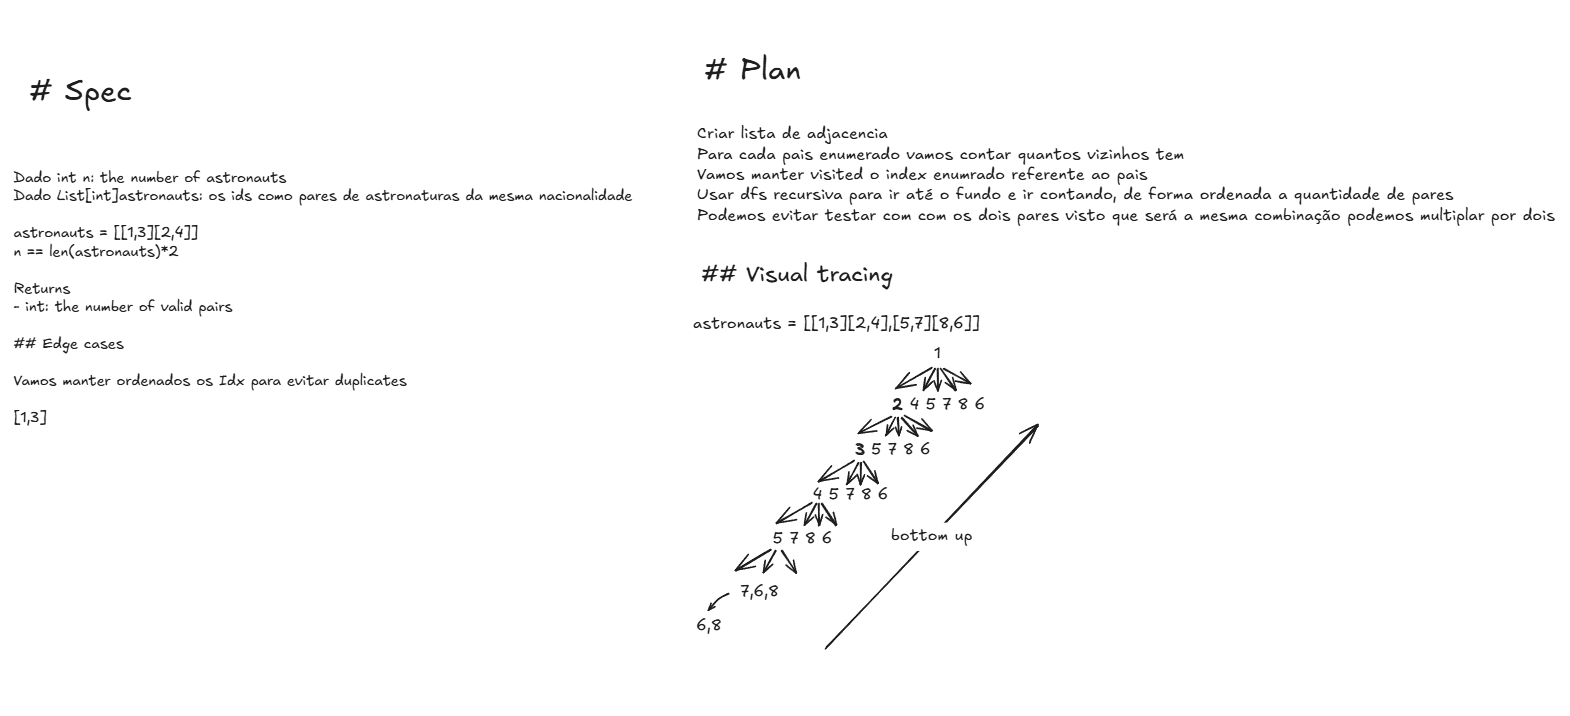

In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys

#
# Complete the 'journeyToMoon' function below.
#
# The function is expected to return an INTEGER.
# The function accepts following parameters:
#  1. INTEGER n
#  2. 2D_INTEGER_ARRAY astronaut
#

from typing import List
from collections import defaultdict

def journeyToMoon(n: int, astronaut: List[List[int]]):
    graph =  defaultdict(list)
    for u,v in  astronaut:
        graph[u].append(v)
        graph[v].append(u)
    visited = set()
    sizes = []
    def dfs(node:int)->int:
        stack = [node]
        size = 0
        while stack:
            current = stack.pop()
            if current in visited:
                continue
                
            visited.add(current)
            size += 1
            
            for neighbor in graph[current]:
                if neighbor in visited:
                    continue
                stack.append(neighbor)
        return size
        
    for i in range(n):
        if i in visited:
            continue
        size = dfs(i)
        sizes.append(size)
            
    total = 0
    acc  = 0
    for i in range(len(sizes)):
        size =  sizes[i]
        total += size * acc
        acc += size
    return total
            
        
if __name__ == '__main__':
    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    first_multiple_input = input().rstrip().split()

    n = int(first_multiple_input[0])

    p = int(first_multiple_input[1])

    astronaut = []

    for _ in range(p):
        astronaut.append(list(map(int, input().rstrip().split())))

    result = journeyToMoon(n, astronaut)

    fptr.write(str(result) + '\n')

    fptr.close()
    fptr.close()
    fptr.close()
